<a href="https://colab.research.google.com/github/Ibrahim-207/Artificial-Intelligence/blob/main/Mosquito_breeding_site_detection_non_hybrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

In [3]:
import os
from tqdm import tqdm
from collections import Counter

# Data Loading

## CheckPoint 1

In [4]:
from sklearn.model_selection import train_test_split
import os

RESIZED_DATA_DIR = '/content/drive/MyDrive/data/update_breed_site_mosq/'

# Get the list of categories (folder names)
categories = os.listdir(RESIZED_DATA_DIR)

# Create lists to store image paths and labels
image_paths = []
labels = []

# Iterate through each category to get image paths and labels
for category in categories:
    category_path = os.path.join(RESIZED_DATA_DIR, category)
    for image_file in os.listdir(category_path):
        image_paths.append(os.path.join(category_path, image_file))
        labels.append(category)  # Use the folder name as the label

# Perform the first split: 70% for training, 30% for the rest (validation + testing)
X_train, X_test, y_train, y_test = train_test_split(image_paths, labels, test_size=0.2, random_state=42, stratify=labels)


print(f"Number of training images: {len(X_train)}")
print(f"Number of testing images: {len(X_test)}")
print(f"Training labels distribution: {pd.Series(y_train).value_counts()}")
print(f"Testing labels distribution: {pd.Series(y_test).value_counts()}")

Number of training images: 600
Number of testing images: 150
Training labels distribution: drain_inlet     200
coconut_crap    200
vase_trash      200
Name: count, dtype: int64
Testing labels distribution: drain_inlet     50
vase_trash      50
coconut_crap    50
Name: count, dtype: int64


In [5]:
import cv2
import os
import numpy as np
from tqdm import tqdm
import shutil
import albumentations as A

# Define augmentation sequence using Albumentations
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(
        scale=(0.8, 1.2),
        rotate=(-25, 25),
        translate_percent={"x": (-0.2, 0.2), "y": (-0.2, 0.2)},
        p=1.0
    ),
    A.RandomBrightnessContrast(brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), p=1.0),
])

# Define the directory to save augmented images
AUGMENTED_DATA_DIR = '/content/drive/MyDrive/data/augmented_breed_site_mosq/'
os.makedirs(AUGMENTED_DATA_DIR, exist_ok=True)

# Copy original training images to the augmented data directory
print("Copying original training images...")
for img_path, label in tqdm(zip(X_train, y_train), total=len(X_train)):
    category_save_dir = os.path.join(AUGMENTED_DATA_DIR, label)
    os.makedirs(category_save_dir, exist_ok=True)
    shutil.copy(img_path, category_save_dir)

# Augment and save images
print("Augmenting and saving images...")

for i, (img_path, label) in tqdm(enumerate(zip(X_train, y_train)), total=len(X_train)):
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert to RGB

    category_save_dir = os.path.join(AUGMENTED_DATA_DIR, label)
    os.makedirs(category_save_dir, exist_ok=True)

    # Apply augmentation 5 times to each image
    for j in range(5):
        augmented_image = transform(image=image)['image']
        save_path = os.path.join(category_save_dir, f"aug_{i}_{j}_{os.path.basename(img_path)}")
        cv2.imwrite(save_path, cv2.cvtColor(augmented_image, cv2.COLOR_RGB2BGR)) # Convert back to BGR for saving


print("Augmentation and saving complete.")

# Count total images in the augmented data directory
total_images = 0
for category in os.listdir(AUGMENTED_DATA_DIR):
    category_path = os.path.join(AUGMENTED_DATA_DIR, category)
    if os.path.isdir(category_path):
        total_images += len(os.listdir(category_path))

print(f"\nTotal number of images in the augmented dataset (including originals): {total_images}")

Copying original training images...


100%|██████████| 600/600 [05:07<00:00,  1.95it/s]


Augmenting and saving images...


100%|██████████| 600/600 [00:32<00:00, 18.22it/s]


Augmentation and saving complete.

Total number of images in the augmented dataset (including originals): 3600


In [6]:
import os
import shutil
from tqdm import tqdm

# Define the directory to save test images
TEST_DATA_DIR = '/content/drive/MyDrive/data/test_breed_site_mosq/'
os.makedirs(TEST_DATA_DIR, exist_ok=True)

# Save test images to the specified directory
print("Saving test images...")
for img_path, label in tqdm(zip(X_test, y_test), total=len(X_test)):
    category_save_dir = os.path.join(TEST_DATA_DIR, label)
    os.makedirs(category_save_dir, exist_ok=True)
    shutil.copy(img_path, category_save_dir)

print("Test images saving complete.")

# Count total images in the test data directory
total_test_images = 0
for category in os.listdir(TEST_DATA_DIR):
    category_path = os.path.join(TEST_DATA_DIR, category)
    if os.path.isdir(category_path):
        total_test_images += len(os.listdir(category_path))

print(f"\nTotal number of images in the test dataset: {total_test_images}")

Saving test images...


100%|██████████| 150/150 [01:16<00:00,  1.95it/s]

Test images saving complete.

Total number of images in the test dataset: 150


## Checkpoint 2

In [7]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Define the directories for augmented training data and test data
AUGMENTED_DATA_DIR = '/content/drive/MyDrive/data/augmented_breed_site_mosq/'
TEST_DATA_DIR = '/content/drive/MyDrive/data/test_breed_site_mosq/'

# Function to load images and labels from a directory
def load_images_from_directory(data_dir):
    images = []
    labels = []
    categories = os.listdir(data_dir)
    for category in categories:
        category_path = os.path.join(data_dir, category)
        if os.path.isdir(category_path):
            print(f"Loading images from category: {category}")
            for image_file in tqdm(os.listdir(category_path)):
                image_path = os.path.join(category_path, image_file)
                image = cv2.imread(image_path)
                if image is not None:
                    # Optionally resize images if needed for consistency
                    # image = cv2.resize(image, (desired_width, desired_height))
                    images.append(image)
                    labels.append(category)
                else:
                    print(f"Warning: Could not load image {image_path}")
    return np.array(images), np.array(labels)

# Load augmented training data
print("Loading augmented training data...")
X_train, y_train = load_images_from_directory(AUGMENTED_DATA_DIR)

# Load test data
print("\nLoading test data...")
X_test, y_test = load_images_from_directory(TEST_DATA_DIR)

print("\nData loading complete.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Loading augmented training data...
Loading images from category: drain_inlet


100%|██████████| 1200/1200 [00:13<00:00, 92.09it/s] 


Loading images from category: coconut_crap


100%|██████████| 1200/1200 [00:11<00:00, 103.44it/s]


Loading images from category: vase_trash


...

Loading images from category: vase_trash


100%|██████████| 50/50 [00:00<00:00, 149.14it/s]


Loading images from category: coconut_crap


100%|██████████| 50/50 [00:00<00:00, 166.49it/s]



Data loading complete.
Shape of X_train: (3600, 224, 224, 3)
Shape of y_train: (3600,)
Shape of X_test: (150, 224, 224, 3)
Shape of y_test: (150,)


# Modeling part

In [8]:
!pip install -q tensorflow

In [9]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.utils import to_categorical # Removed one-hot encoding
import numpy as np

# Split augmented training data into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

# Convert labels to integers
unique_labels = np.unique(y_train)
label_to_int = {label: i for i, label in enumerate(unique_labels)}
int_to_label = {i: label for i, label in enumerate(unique_labels)}

y_train_int = np.array([label_to_int[label] for label in y_train_split])
y_val_int = np.array([label_to_int[label] for label in y_val_split])
y_test_int = np.array([label_to_int[label] for label in y_test])


## Hybrid Densenet121 + LightGbm

In [12]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Model
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D # Import GlobalAveragePooling2D
import numpy as np

# Load DenseNet121 pre-trained on ImageNet
# We will use this as a feature extractor
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add GlobalAveragePooling2D layer to the base model output
x = base_model.output
x = GlobalAveragePooling2D()(x)

# Create a new model that outputs the features
feature_extractor = Model(inputs=base_model.input, outputs=x)

# Extract features from the training and test data
print("Extracting features from training data...")
X_train_features = feature_extractor.predict(X_train_split)
print("Extracting features from validation data...")
X_val_features = feature_extractor.predict(X_val_split)
print("Extracting features from test data...")
X_test_features = feature_extractor.predict(X_test)


# Initialize and train a LightGBM classifier
lgb_clf = lgb.LGBMClassifier(objective='multiclass', num_class=len(unique_labels),
                             n_estimators=500,
                             device='gpu',
                             )

print("\nTraining LightGBM model...")
lgb_clf.fit(X_train_features, y_train_int)

# Make predictions on the test set
y_pred = lgb_clf.predict(X_test_features)

# Evaluate the model
accuracy = accuracy_score(y_test_int, y_pred)
print(f"\nLightGBM Accuracy on the test set: {accuracy}")

Extracting features from training data...
102/102 ━━━━━━━━━━━━━━━━━━━━ 33s 207ms/step
Extracting features from validation data...
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step
Extracting features from test data...
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step

Training LightGBM model...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 260693
[LightGBM] [Info] Number of data points in the train set: 3240, number of used features: 1024
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 1009 dense feature groups (3.13 MB) transferred to GPU in 0.007872 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with posit

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [13]:
from sklearn.metrics import classification_report
import numpy as np # Import numpy to handle np.str_

# Generate classification report
report = classification_report(y_test_int, y_pred, target_names=unique_labels)

# Print the classification report
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

coconut_crap       0.94      0.90      0.92        50
 drain_inlet       0.92      0.96      0.94        50
  vase_trash       0.98      0.98      0.98        50

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



In [33]:
# Define the path to save the model
model_save_path = '/content/drive/MyDrive/densenet_breed_site_mosq_model.keras'

# Save the model
model.save(model_save_path)

print(f"DenseNet model saved successfully to {model_save_path}")

DenseNet model saved successfully to /content/drive/MyDrive/densenet_breed_site_mosq_model.keras


## DenseNet121

In [26]:
# Load DenseNet121 pre-trained on ImageNet
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add custom layers for fine-tuning
x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(len(unique_labels), activation='softmax')(x) # Number of output classes

model = Model(inputs=base_model.input, outputs=predictions)

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy']) # Changed loss function

# Train the model
epochs = 10 # You can adjust the number of epochs
batch_size = 32 # You can adjust the batch size

history = model.fit(
    X_train_split, y_train_int, # Use integer labels
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_split, y_val_int) # Use integer labels
)

# Fine-tune the model (unfreeze some layers and train with a lower learning rate)

# Unfreeze some layers
for layer in base_model.layers[-50:]: # Unfreeze the last 50 layers of the base model
    layer.trainable = True

# Recompile the model with a lower learning rate
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy']) # Changed loss function

# Continue training (fine-tuning)
epochs_fine_tune = 10 # You can adjust the number of fine-tuning epochs

history_fine_tune = model.fit(
    X_train_split, y_train_int, # Use integer labels
    epochs=epochs_fine_tune,
    batch_size=batch_size, # Changed from batch_size_mobilenet
    validation_data=(X_val_split, y_val_int) # Use integer labels
)

print("Model training complete.")

Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 63s 405ms/step - accuracy: 0.5084 - loss: 1.4103 - val_accuracy: 0.6889 - val_loss: 0.7996
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.7131 - loss: 0.7348 - val_accuracy: 0.7222 - val_loss: 0.6401
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.7325 - loss: 0.6174 - val_accuracy: 0.7944 - val_loss: 0.5310
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.7924 - loss: 0.5030 - val_accuracy: 0.8028 - val_loss: 0.5531
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.8163 - loss: 0.4618 - val_accuracy: 0.7972 - val_loss: 0.5037
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.8239 - loss: 0.4329 - val_accuracy: 0.8417 - val_loss: 0.4467
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.8434 - loss: 0.4110 - val_accuracy: 0.8306 - val_loss: 0.4478
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.8568 - loss: 0.3679 - val_ac

In [27]:
from sklearn.metrics import classification_report
import numpy as np

# Make predictions on the test set using the trained DenseNet model
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Generate classification report
report = classification_report(y_test_int, y_pred_classes, target_names=unique_labels)

# Print the classification report
print("Classification Report for DenseNet Model:")
print(report)

5/5 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step
Classification Report for DenseNet Model:
              precision    recall  f1-score   support

coconut_crap       0.94      0.96      0.95        50
 drain_inlet       0.98      0.96      0.97        50
  vase_trash       0.98      0.98      0.98        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



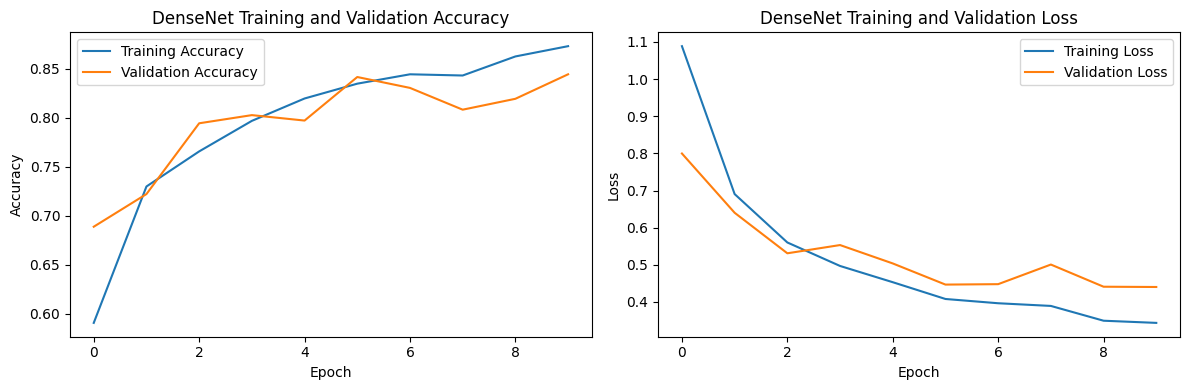

In [31]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('DenseNet Training and Validation Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DenseNet Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
# Define the path to save the model
model_save_path = '/content/drive/MyDrive/densenet_breed_site_mosq_model.keras'

# Save the model
model.save(model_save_path)

print(f"DenseNet model saved successfully to {model_save_path}")

DenseNet model saved successfully to /content/drive/MyDrive/densenet_breed_site_mosq_model.keras


## MobileNetV2

In [34]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping # Import EarlyStopping

# Load MobileNetV2 pre-trained on ImageNet
base_model_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add custom layers for fine-tuning
x = base_model_mobilenet.output
x = GlobalAveragePooling2D()(x)
predictions_mobilenet = Dense(len(unique_labels), activation='softmax')(x) # Number of output classes

model_mobilenet = Model(inputs=base_model_mobilenet.input, outputs=predictions_mobilenet)

# Freeze the layers of the base model
for layer in base_model_mobilenet.layers:
    layer.trainable = False

# Compile the model
model_mobilenet.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


# Train the model
epochs_mobilenet = 10 # You can adjust the number of epochs
batch_size_mobilenet = 32 # You can adjust the batch size

history_mobilenet = model_mobilenet.fit(
    X_train_split, y_train_int, # Use integer labels
    epochs=epochs_mobilenet,
    batch_size=batch_size_mobilenet,
    validation_data=(X_val_split, y_val_int), # Use integer labels
    callbacks=[early_stopping] # Add early stopping callback
)

# Fine-tune the model (unfreeze some layers and train with a lower learning rate)

# Unfreeze some layers
for layer in base_model_mobilenet.layers[-30:]: # Unfreeze the last 30 layers of the base model
    layer.trainable = True

# Recompile the model with a lower learning rate
model_mobilenet.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Continue training (fine-tuning)
epochs_fine_tune_mobilenet = 10 # You can adjust the number of fine-tuning epochs

history_fine_tune_mobilenet = model_mobilenet.fit(
    X_train_split, y_train_int, # Use integer labels
    epochs=epochs_fine_tune_mobilenet,
    batch_size=batch_size_mobilenet,
    validation_data=(X_val_split, y_val_int), # Use integer labels
    callbacks=[early_stopping] # Add early stopping callback
)

print("MobileNetV2 model training complete.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 38s 212ms/step - accuracy: 0.4367 - loss: 1.1064 - val_accuracy: 0.6194 - val_loss: 0.8417
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6598 - loss: 0.7721 - val_accuracy: 0.6972 - val_loss: 0.7348
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.7102 - loss: 0.6945 - val_accuracy: 0.7083 - val_loss: 0.6890
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7389 - loss: 0.6377 - val_accuracy: 0.7361 - val_loss: 0.6601
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7446 - loss: 0.6147 - val_accuracy: 0.7056 - val_loss: 0.6551
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7869 - loss: 0.5594 - val_accuracy: 0.7194 - val_loss: 0.6613
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.7579 - loss: 0.5822 - val_accuracy: 0.7333 - val_loss: 0.6183
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 29m

3/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step
Classification Report for MobileNetV2 Model:
              precision    recall  f1-score   support

coconut_crap       0.83      0.78      0.80        50
 drain_inlet       0.83      0.90      0.87        50
  vase_trash       0.90      0.88      0.89        50

    accuracy                           0.85       150
   macro avg       0.85      0.85      0.85       150
weighted avg       0.85      0.85      0.85       150



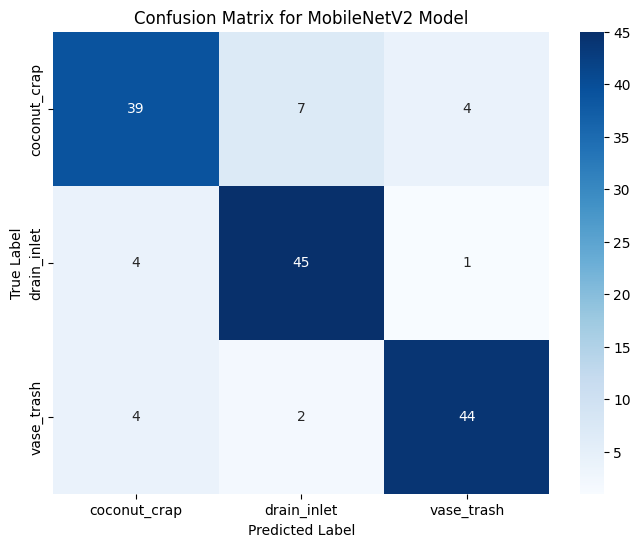

In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on the test set using the trained MobileNetV2 model
y_pred_probs_mobilenet = model_mobilenet.predict(X_test)
y_pred_classes_mobilenet = np.argmax(y_pred_probs_mobilenet, axis=1)

# Generate classification report
report_mobilenet = classification_report(y_test_int, y_pred_classes_mobilenet, target_names=unique_labels)

# Print the classification report
print("Classification Report for MobileNetV2 Model:")
print(report_mobilenet)

# Generate the confusion matrix
cm_mobilenet = confusion_matrix(y_test_int, y_pred_classes_mobilenet)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mobilenet, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for MobileNetV2 Model')
plt.show()

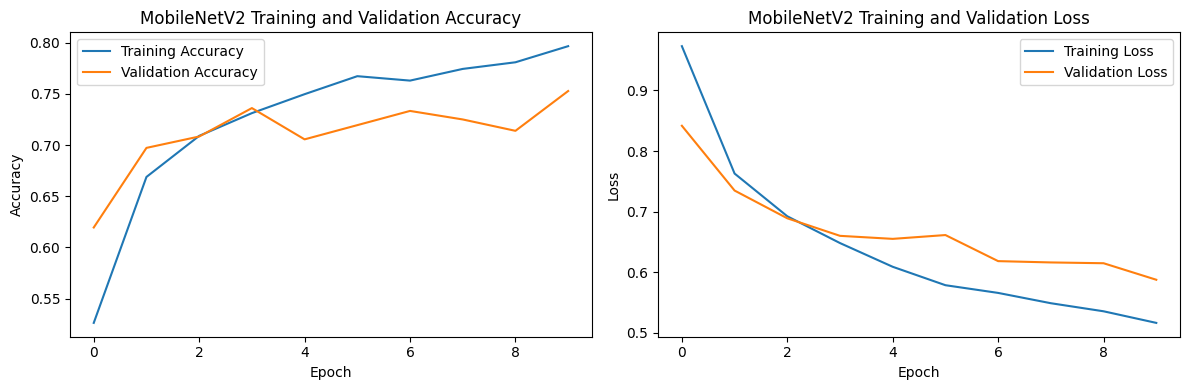

In [37]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_mobilenet.history['accuracy'], label='Training Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MobileNetV2 Training and Validation Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history_mobilenet.history['loss'], label='Training Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MobileNetV2 Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
# Define the path to save the MobileNetV2 model
model_save_path_mobilenet = '/content/drive/MyDrive/mobilenetv2_breed_site_mosq_model.keras'

# Save the MobileNetV2 model
model_mobilenet.save(model_save_path_mobilenet)

print(f"MobileNetV2 model saved successfully to {model_save_path_mobilenet}")

MobileNetV2 model saved successfully to /content/drive/MyDrive/mobilenetv2_breed_site_mosq_model.keras


## VGG16

In [43]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping # Import EarlyStopping

# Load VGG16 pre-trained on ImageNet
base_model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add custom layers for fine-tuning
x = base_model_vgg.output
x = Flatten()(x) # Use Flatten for VGG16
x = Dense(512, activation='relu')(x) # Add a dense layer
predictions_vgg = Dense(len(unique_labels), activation='softmax')(x) # Number of output classes

model_vgg = Model(inputs=base_model_vgg.input, outputs=predictions_vgg)

# Freeze the layers of the base model
for layer in base_model_vgg.layers:
    layer.trainable = False

# Compile the model
model_vgg.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
epochs_vgg = 10 # You can adjust the number of epochs
batch_size_vgg = 32 # You can adjust the batch size

history_vgg = model_vgg.fit(
    X_train_split, y_train_int, # Use integer labels
    epochs=epochs_vgg,
    batch_size=batch_size_vgg,
    validation_data=(X_val_split, y_val_int), # Use integer labels
    callbacks=[early_stopping] # Add early stopping callback
)

# Fine-tune the model (unfreeze some layers and train with a lower learning rate)

# Unfreeze some layers
for layer in base_model_vgg.layers[-5:]: # Unfreeze the last few layers of the base model
    layer.trainable = True

# Recompile the model with a lower learning rate
model_vgg.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Continue training (fine-tuning)
epochs_fine_tune_vgg = 10 # You can adjust the number of fine-tuning epochs

history_fine_tune_vgg = model_vgg.fit(
    X_train_split, y_train_int, # Use integer labels
    epochs=epochs_fine_tune_vgg,
    batch_size=batch_size_vgg,
    validation_data=(X_val_split, y_val_int), # Use integer labels
    callbacks=[early_stopping] # Add early stopping callback
)

print("VGG16 model training complete.")

Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 24s 215ms/step - accuracy: 0.7811 - loss: 11.0595 - val_accuracy: 0.9417 - val_loss: 0.2763
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 20s 193ms/step - accuracy: 0.9750 - loss: 0.1483 - val_accuracy: 0.9361 - val_loss: 0.4162
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 19s 187ms/step - accuracy: 0.9897 - loss: 0.0362 - val_accuracy: 0.9611 - val_loss: 0.2625
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 19s 186ms/step - accuracy: 0.9965 - loss: 0.0124 - val_accuracy: 0.9556 - val_loss: 0.2571
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 19s 188ms/step - accuracy: 0.9991 - loss: 0.0044 - val_accuracy: 0.9583 - val_loss: 0.1784
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 19s 189ms/step - accuracy: 1.0000 - loss: 5.4621e-05 - val_accuracy: 0.9583 - val_loss: 0.1791
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 19s 187ms/step - accuracy: 1.0000 - loss: 1.9134e-05 - val_accuracy: 0.9583 - val_loss: 0.1816
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 19s 187ms/step - accuracy: 1.0000 

In [44]:
from sklearn.metrics import classification_report
import numpy as np

# Make predictions on the test set using the trained VGG16 model
y_pred_probs_vgg = model_vgg.predict(X_test)
y_pred_classes_vgg = np.argmax(y_pred_probs_vgg, axis=1)

# Generate classification report
report_vgg = classification_report(y_test_int, y_pred_classes_vgg, target_names=unique_labels)

# Print the classification report
print("Classification Report for VGG16 Model:")
print(report_vgg)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 301ms/step
Classification Report for VGG16 Model:
              precision    recall  f1-score   support

coconut_crap       0.96      0.94      0.95        50
 drain_inlet       0.96      0.98      0.97        50
  vase_trash       0.96      0.96      0.96        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step


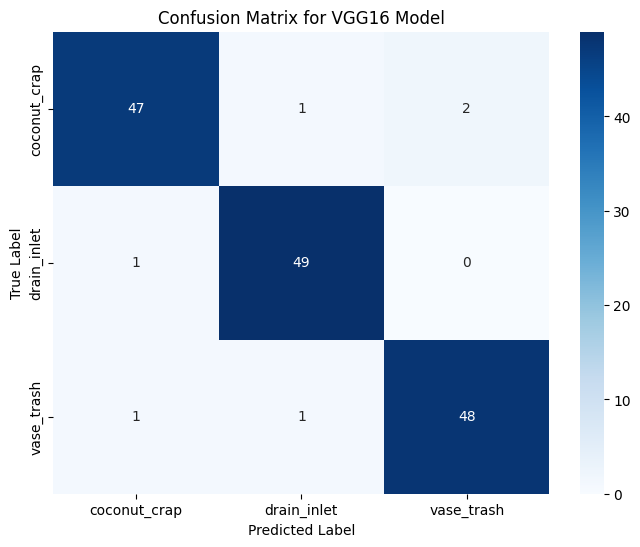

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on the test set using the trained VGG16 model
y_pred_probs_vgg = model_vgg.predict(X_test)
y_pred_classes_vgg = np.argmax(y_pred_probs_vgg, axis=1)

# Generate the confusion matrix
cm_vgg = confusion_matrix(y_test_int, y_pred_classes_vgg)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for VGG16 Model')
plt.show()

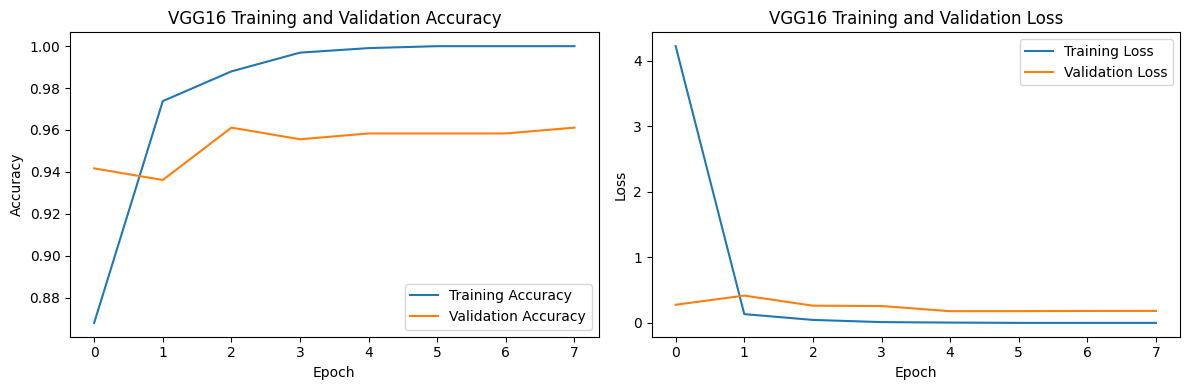

In [46]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('VGG16 Training and Validation Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['loss'], label='Training Loss')
plt.plot(history_vgg.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VGG16 Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [47]:
# Define the path to save the model
model_save_path_vgg = '/content/drive/MyDrive/vgg16_breed_site_mosq_model.keras'

# Save the VGG16 model
model_vgg.save(model_save_path_vgg)

print(f"VGG16 model saved successfully to {model_save_path_vgg}")

VGG16 model saved successfully to /content/drive/MyDrive/vgg16_breed_site_mosq_model.keras


##VGG19

In [4]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Load VGG19 pre-trained on ImageNet
base_model_vgg19 = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add custom layers for fine-tuning
x = base_model_vgg19.output
x = Flatten()(x) # Use Flatten for VGG19
x = Dense(512, activation='relu')(x) # Add a dense layer
predictions_vgg19 = Dense(len(unique_labels), activation='softmax')(x) # Number of output classes

model_vgg19 = Model(inputs=base_model_vgg19.input, outputs=predictions_vgg19)

# Freeze the layers of the base model
for layer in base_model_vgg19.layers:
    layer.trainable = False

# Compile the model
model_vgg19.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define EarlyStopping callback
early_stopping_vgg19 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
epochs_vgg19 = 10 # You can adjust the number of epochs
batch_size_vgg19 = 32 # You can adjust the batch size

history_vgg19 = model_vgg19.fit(
    X_train_split, y_train_int, # Use integer labels
    epochs=epochs_vgg19,
    batch_size=batch_size_vgg19,
    validation_data=(X_val_split, y_val_int), # Use integer labels
    callbacks=[early_stopping_vgg19] # Add early stopping callback
)

# Fine-tune the model (unfreeze some layers and train with a lower learning rate)

# Unfreeze some layers
for layer in base_model_vgg19.layers[-5:]: # Unfreeze the last few layers of the base model
    layer.trainable = True

# Recompile the model with a lower learning rate
model_vgg19.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Continue training (fine-tuning)
epochs_fine_tune_vgg19 = 10 # You can adjust the number of fine-tuning epochs

history_fine_tune_vgg19 = model_vgg19.fit(
    X_train_split, y_train_int, # Use integer labels
    epochs=epochs_fine_tune_vgg19,
    batch_size=batch_size_vgg19,
    validation_data=(X_val_split, y_val_int), # Use integer labels
    callbacks=[early_stopping_vgg19] # Add early stopping callback
)

print("VGG19 model training complete.")

NameError: name 'unique_labels' is not defined

In [1]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on the test set using the trained VGG19 model
y_pred_probs_vgg19 = model_vgg19.predict(X_test)
y_pred_classes_vgg19 = np.argmax(y_pred_probs_vgg19, axis=1)

# Generate classification report
report_vgg19 = classification_report(y_test_int, y_pred_classes_vgg19, target_names=unique_labels)

# Print the classification report
print("Classification Report for VGG19 Model:")
print(report_vgg19)

# Generate the confusion matrix
cm_vgg19 = confusion_matrix(y_test_int, y_pred_classes_vgg19)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_vgg19, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for VGG19 Model')
plt.show()

NameError: name 'model_vgg19' is not defined

NameError: name 'history_vgg19' is not defined

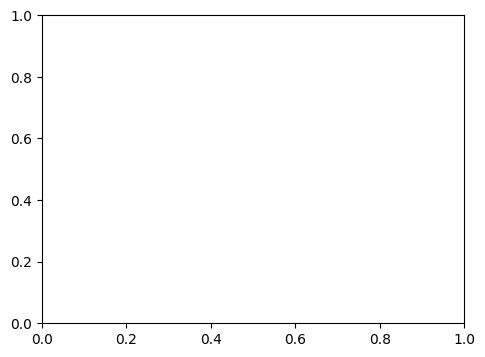

In [2]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_vgg19.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg19.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('VGG19 Training and Validation Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history_vgg19.history['loss'], label='Training Loss')
plt.plot(history_vgg19.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VGG19 Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [3]:
# Define the path to save the MobileNetV2 model
model_save_path_vgg19 = '/content/drive/MyDrive/vgg19_breed_site_mosq_model.keras'

# Save the MobileNetV2 model
model_vgg19.save(model_save_path_vgg19)

print(f"VGG19 model saved successfully to {model_save_path_vgg19}")

NameError: name 'model_vgg19' is not defined

##ResNet50

In [48]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Load ResNet50 pre-trained on ImageNet
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add custom layers for fine-tuning
x = base_model_resnet.output
x = GlobalAveragePooling2D()(x)
predictions_resnet = Dense(len(unique_labels), activation='softmax')(x) # Number of output classes

model_resnet = Model(inputs=base_model_resnet.input, outputs=predictions_resnet)

# Freeze the layers of the base model
for layer in base_model_resnet.layers:
    layer.trainable = False

# Compile the model
model_resnet.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define EarlyStopping callback
early_stopping_resnet = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
epochs_resnet = 10 # You can adjust the number of epochs
batch_size_resnet = 32 # You can adjust the batch size

history_resnet = model_resnet.fit(
    X_train_split, y_train_int, # Use integer labels
    epochs=epochs_resnet,
    batch_size=batch_size_resnet,
    validation_data=(X_val_split, y_val_int), # Use integer labels
    callbacks=[early_stopping_resnet] # Add early stopping callback
)

# Fine-tune the model (unfreeze some layers and train with a lower learning rate)

# Unfreeze some layers
for layer in base_model_resnet.layers[-30:]: # Unfreeze the last 30 layers of the base model
    layer.trainable = True

# Recompile the model with a lower learning rate
model_resnet.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Continue training (fine-tuning)
epochs_fine_tune_resnet = 10 # You can adjust the number of fine-tuning epochs

history_fine_tune_resnet = model_resnet.fit(
    X_train_split, y_train_int, # Use integer labels
    epochs=epochs_fine_tune_resnet,
    batch_size=batch_size_resnet,
    validation_data=(X_val_split, y_val_int), # Use integer labels
    callbacks=[early_stopping_resnet] # Add early stopping callback
)

print("ResNet50 model training complete.")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 34s 215ms/step - accuracy: 0.7103 - loss: 0.6695 - val_accuracy: 0.9333 - val_loss: 0.1689
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.9470 - loss: 0.1584 - val_accuracy: 0.9556 - val_loss: 0.1205
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.9709 - loss: 0.1004 - val_accuracy: 0.9694 - val_loss: 0.1065
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.9852 - loss: 0.0667 - val_accuracy: 0.9694 - val_loss: 0.0866
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.9851 - loss: 0.0592 - val_accuracy: 0.9806 - val_loss: 0.0710
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.9926 - loss: 0.0439 - val_accuracy: 0.9861 - val_loss: 0.0623
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.9986 - loss: 0.0364 - val_accuracy: 0.9833 - val_loss: 0.0565
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 9s 

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
Classification Report for ResNet50 Model:
              precision    recall  f1-score   support

coconut_crap       0.94      0.98      0.96        50
 drain_inlet       0.96      0.96      0.96        50
  vase_trash       1.00      0.96      0.98        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



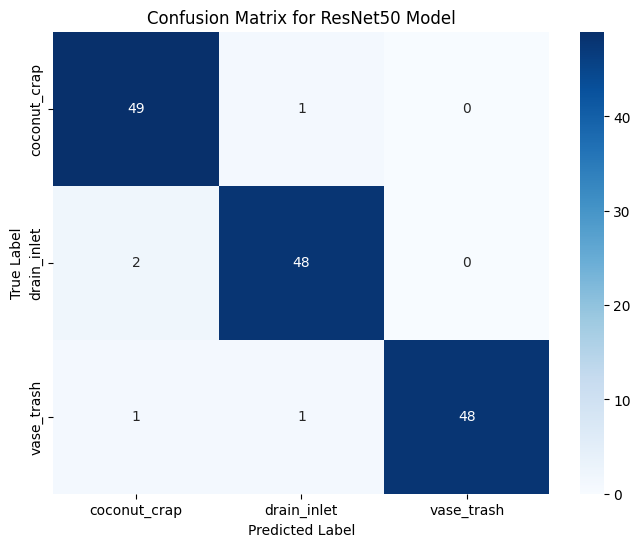

In [49]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on the test set using the trained ResNet50 model
y_pred_probs_resnet = model_resnet.predict(X_test)
y_pred_classes_resnet = np.argmax(y_pred_probs_resnet, axis=1)

# Generate classification report
report_resnet = classification_report(y_test_int, y_pred_classes_resnet, target_names=unique_labels)

# Print the classification report
print("Classification Report for ResNet50 Model:")
print(report_resnet)

# Generate the confusion matrix
cm_resnet = confusion_matrix(y_test_int, y_pred_classes_resnet)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for ResNet50 Model')
plt.show()

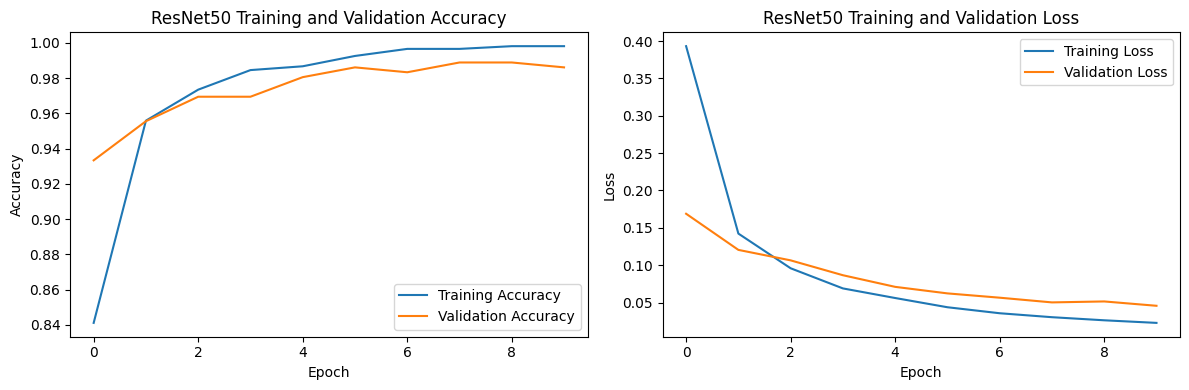

In [50]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['accuracy'], label='Training Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ResNet50 Training and Validation Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['loss'], label='Training Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNet50 Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [51]:
# Define the path to save the model
model_save_path_resnet = '/content/drive/MyDrive/resnet50_breed_site_mosq_model.keras'

# Save the ResNet50 model
model_resnet.save(model_save_path_resnet)

print(f"ResNet50 model saved successfully to {model_save_path_resnet}")

ResNet50 model saved successfully to /content/drive/MyDrive/resnet50_breed_site_mosq_model.keras


##ResNet101

In [52]:
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Load ResNet101 pre-trained on ImageNet
base_model_resnet101 = ResNet101(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add custom layers for fine-tuning
x = base_model_resnet101.output
x = GlobalAveragePooling2D()(x)
predictions_resnet101 = Dense(len(unique_labels), activation='softmax')(x) # Number of output classes

model_resnet101 = Model(inputs=base_model_resnet101.input, outputs=predictions_resnet101)

# Freeze the layers of the base model
for layer in base_model_resnet101.layers:
    layer.trainable = False

# Compile the model
model_resnet101.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define EarlyStopping callback
early_stopping_resnet101 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
epochs_resnet101 = 10 # You can adjust the number of epochs
batch_size_resnet101 = 32 # You can adjust the batch size

history_resnet101 = model_resnet101.fit(
    X_train_split, y_train_int, # Use integer labels
    epochs=epochs_resnet101,
    batch_size=batch_size_resnet101,
    validation_data=(X_val_split, y_val_int), # Use integer labels
    callbacks=[early_stopping_resnet101] # Add early stopping callback
)

# Fine-tune the model (unfreeze some layers and train with a lower learning rate)

# Unfreeze some layers
for layer in base_model_resnet101.layers[-30:]: # Unfreeze the last 30 layers of the base model
    layer.trainable = True

# Recompile the model with a lower learning rate
model_resnet101.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Continue training (fine-tuning)
epochs_fine_tune_resnet101 = 10 # You can adjust the number of fine-tuning epochs

history_fine_tune_resnet101 = model_resnet101.fit(
    X_train_split, y_train_int, # Use integer labels
    epochs=epochs_fine_tune_resnet101,
    batch_size=batch_size_resnet101,
    validation_data=(X_val_split, y_val_int), # Use integer labels
    callbacks=[early_stopping_resnet101] # Add early stopping callback
)

print("ResNet101 model training complete.")

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 51s 336ms/step - accuracy: 0.7465 - loss: 0.5833 - val_accuracy: 0.9639 - val_loss: 0.1260
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 18s 174ms/step - accuracy: 0.9624 - loss: 0.1215 - val_accuracy: 0.9861 - val_loss: 0.0781
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 18s 177ms/step - accuracy: 0.9792 - loss: 0.0863 - val_accuracy: 0.9944 - val_loss: 0.0546
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 18s 173ms/step - accuracy: 0.9842 - loss: 0.0606 - val_accuracy: 0.9917 - val_loss: 0.0425
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 18s 173ms/step - accuracy: 0.9948 - loss: 0.0411 - val_accuracy: 0.9972 - val_loss: 0.0349
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 18s 173ms/step - accuracy: 0.9959 - loss: 0.0329 - val_accuracy: 0.9944 - val_loss: 0.0300
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 18s 173ms/step - accuracy: 0.9969 - loss: 0.0283 - val_accuracy: 0.9944 - val_loss: 0.0279
Epoch 8/10
102/102 ━━━━━━━━━━

5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step
Classification Report for ResNet101 Model:
              precision    recall  f1-score   support

coconut_crap       0.98      1.00      0.99        50
 drain_inlet       0.98      1.00      0.99        50
  vase_trash       1.00      0.96      0.98        50

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



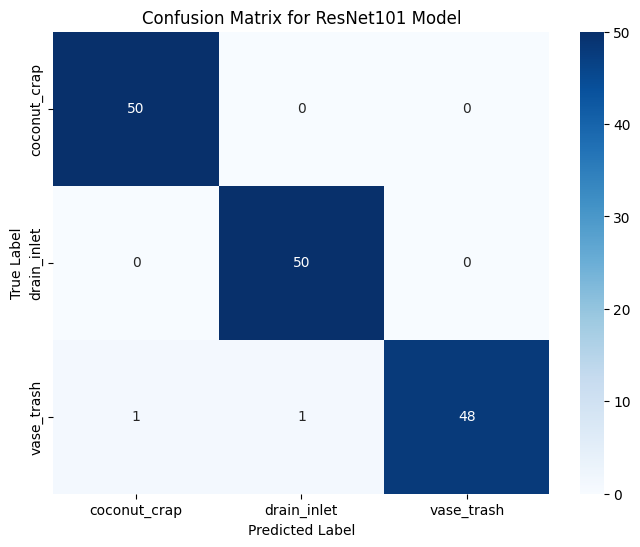

In [53]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on the test set using the trained ResNet101 model
y_pred_probs_resnet101 = model_resnet101.predict(X_test)
y_pred_classes_resnet101 = np.argmax(y_pred_probs_resnet101, axis=1)

# Generate classification report
report_resnet101 = classification_report(y_test_int, y_pred_classes_resnet101, target_names=unique_labels)

# Print the classification report
print("Classification Report for ResNet101 Model:")
print(report_resnet101)

# Generate the confusion matrix
cm_resnet101 = confusion_matrix(y_test_int, y_pred_classes_resnet101)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_resnet101, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for ResNet101 Model')
plt.show()

# Comparison

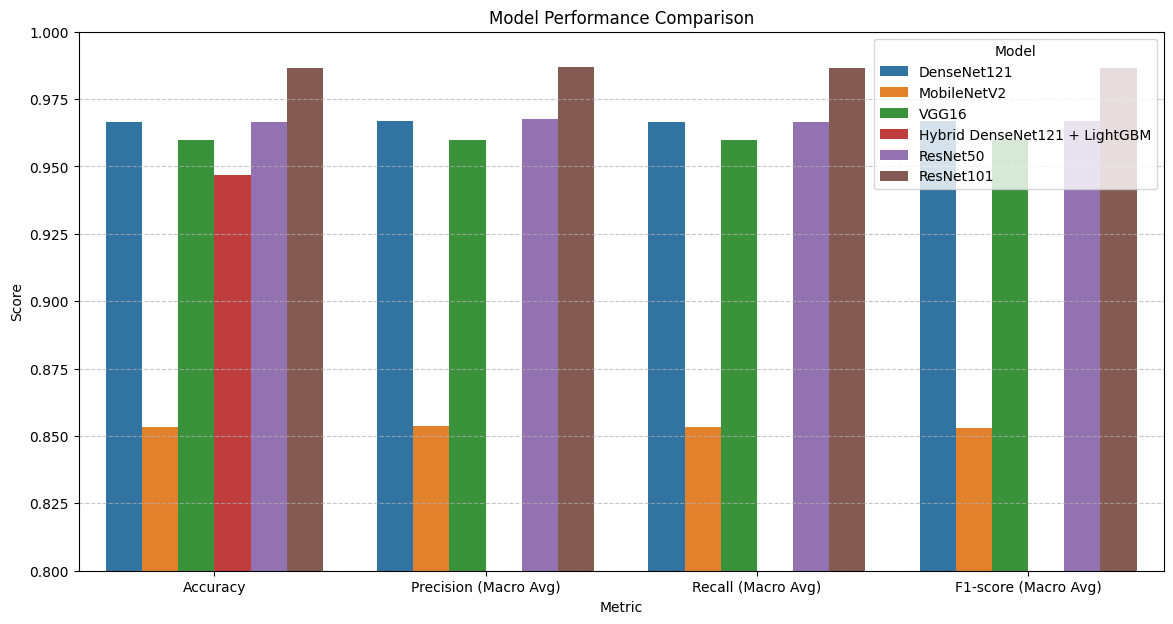

,Model,Accuracy,Precision (Macro Avg),Recall (Macro Avg),F1-score (Macro Avg)
0,DenseNet121,0.966667,0.966923,0.966667,0.966731
1,MobileNetV2,0.853333,0.853693,0.853333,0.852799
2,VGG16,0.960000,0.959989,0.960000,0.959931
3,Hybrid DenseNet121 + LightGBM,0.946667,NaN,NaN,NaN
4,ResNet50,0.966667,0.967436,0.966667,0.966792
5,ResNet101,0.986667,0.986928,0.986667,0.986597


In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# --- Extract metrics for DenseNet ---
# Assuming y_test_int and y_pred_classes are available from previous DenseNet evaluation
report_densenet = classification_report(y_test_int, y_pred_classes, target_names=unique_labels, output_dict=True)
densenet_metrics = {
    'Model': 'DenseNet121',
    'Accuracy': report_densenet['accuracy'],
    'Precision (Macro Avg)': report_densenet['macro avg']['precision'],
    'Recall (Macro Avg)': report_densenet['macro avg']['recall'],
    'F1-score (Macro Avg)': report_densenet['macro avg']['f1-score']
}

# --- Extract metrics for MobileNetV2 ---
# Assuming y_test_int and y_pred_classes_mobilenet are available from previous MobileNetV2 evaluation
report_mobilenet = classification_report(y_test_int, y_pred_classes_mobilenet, target_names=unique_labels, output_dict=True)
mobilenet_metrics = {
    'Model': 'MobileNetV2',
    'Accuracy': report_mobilenet['accuracy'],
    'Precision (Macro Avg)': report_mobilenet['macro avg']['precision'],
    'Recall (Macro Avg)': report_mobilenet['macro avg']['recall'],
    'F1-score (Macro Avg)': report_mobilenet['macro avg']['f1-score']
}

# --- Extract metrics for VGG16 ---
# Assuming y_test_int and y_pred_classes_vgg are available from previous VGG16 evaluation
report_vgg = classification_report(y_test_int, y_pred_classes_vgg, target_names=unique_labels, output_dict=True)
vgg_metrics = {
    'Model': 'VGG16',
    'Accuracy': report_vgg['accuracy'],
    'Precision (Macro Avg)': report_vgg['macro avg']['precision'],
    'Recall (Macro Avg)': report_vgg['macro avg']['recall'],
    'F1-score (Macro Avg)': report_vgg['macro avg']['f1-score']
}

# --- Extract metrics for Hybrid DenseNet121 + LightGBM ---
# Assuming accuracy is available from the LightGBM evaluation
hybrid_lgbm_metrics = {
    'Model': 'Hybrid DenseNet121 + LightGBM',
    'Accuracy': accuracy, # Use the 'accuracy' variable from the LGBM evaluation
    'Precision (Macro Avg)': None, # Precision, Recall, F1-score were not explicitly calculated for LGBM in the previous steps
    'Recall (Macro Avg)': None,
    'F1-score (Macro Avg)': None
}

# --- Extract metrics for ResNet50 ---
# Assuming y_test_int and y_pred_classes_resnet are available from previous ResNet50 evaluation
report_resnet = classification_report(y_test_int, y_pred_classes_resnet, target_names=unique_labels, output_dict=True)
resnet_metrics = {
    'Model': 'ResNet50',
    'Accuracy': report_resnet['accuracy'],
    'Precision (Macro Avg)': report_resnet['macro avg']['precision'],
    'Recall (Macro Avg)': report_resnet['macro avg']['recall'],
    'F1-score (Macro Avg)': report_resnet['macro avg']['f1-score']
}

# --- Extract metrics for ResNet101 ---
# Assuming y_test_int and y_pred_classes_resnet101 are available from previous ResNet101 evaluation
report_resnet101 = classification_report(y_test_int, y_pred_classes_resnet101, target_names=unique_labels, output_dict=True)
resnet101_metrics = {
    'Model': 'ResNet101',
    'Accuracy': report_resnet101['accuracy'],
    'Precision (Macro Avg)': report_resnet101['macro avg']['precision'],
    'Recall (Macro Avg)': report_resnet101['macro avg']['recall'],
    'F1-score (Macro Avg)': report_resnet101['macro avg']['f1-score']
}

# Create a DataFrame
df_comparison = pd.DataFrame([densenet_metrics, mobilenet_metrics, vgg_metrics, hybrid_lgbm_metrics, resnet_metrics, resnet101_metrics])

# Melt the DataFrame for plotting
df_melted = df_comparison.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Plot the comparison using Seaborn
plt.figure(figsize=(14, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.8, 1.0) # Adjusted y-axis limit to show better differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

display(df_comparison)

#Best To Model Selection

In [56]:
# Sort the DataFrame by Accuracy in descending order and display the top 2 models
best_models = df_comparison.sort_values(by='Accuracy', ascending=False).head(2)
print("Top 2 models based on Accuracy:")
display(best_models)

Top 2 models based on Accuracy:


,Model,Accuracy,Precision (Macro Avg),Recall (Macro Avg),F1-score (Macro Avg)
5,ResNet101,0.986667,0.986928,0.986667,0.986597
0,DenseNet121,0.966667,0.966923,0.966667,0.966731
